In [18]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
sys.path.append(str(ROOT_DIR / 'src'))

import plotting as plot_utils

processed_path = ROOT_DIR / 'data' / 'processed' / 'reading_habits_cleaned.csv'
figures_path = ROOT_DIR / 'figures'

df = pd.read_csv(processed_path)
print(f'Datos cargados: {df.shape}')

Datos cargados: (2832, 19)


Gráfico guardado en: c:\Users\micaa\book-consumption-analysis\figures\reader_segments_distribution.png


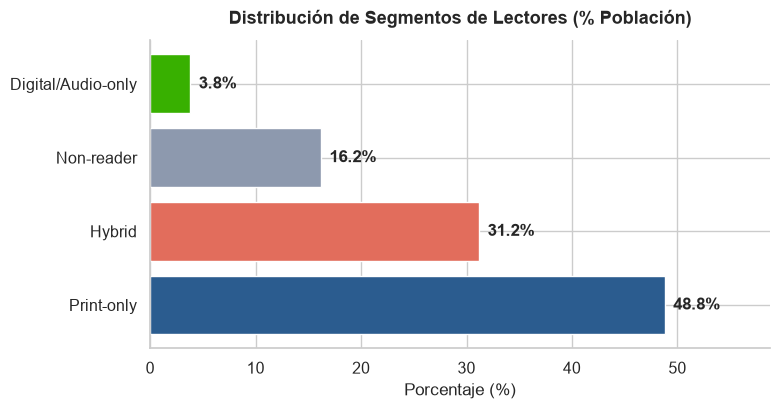

c:\Users\micaa\book-consumption-analysis\src\plotting.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Gráfico guardado en: c:\Users\micaa\book-consumption-analysis\figures\books_read_by_segment.png


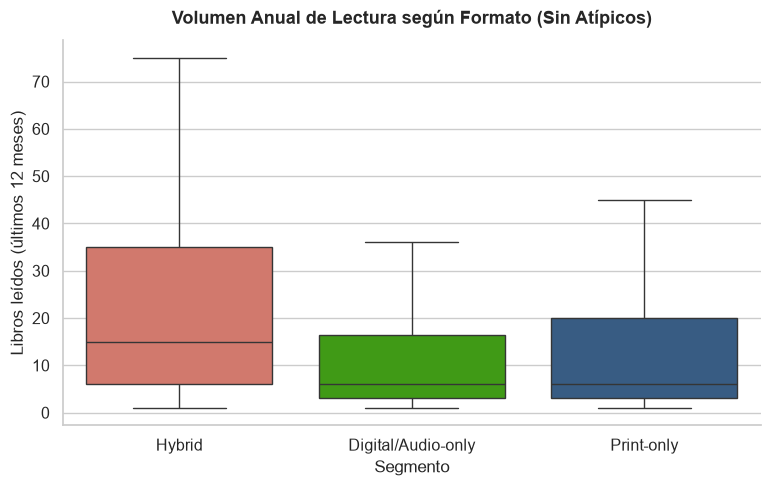

In [19]:
# Gráfico 1: Proporción de la población por segmento
fig1 = plot_utils.plot_segments_distribution(df, figures_path)
plt.show()

  # Gráfico 2: ¿Quién lee más cantidad de libros al año?
fig2 = plot_utils.plot_books_read_by_segment(df, figures_path)
plt.show()

In [20]:
age_summary = (
    df.groupby('reader_segment')['age']
    .agg(media='mean', mediana='median', desviación='std')
    .round(1)
)
print('--- Edad promedio por segmento ---')
print(age_summary)

--- Edad promedio por segmento ---
                    media  mediana  desviación
reader_segment                                
Digital/Audio-only   43.5     41.0        17.2
Hybrid               45.7     47.0        17.0
Non-reader           50.8     52.0        18.9
Print-only           47.4     49.0        19.4


In [12]:
edu_digital = (
      df.groupby('education')['is_digital_adopter']
      .mean()
      .mul(100)
      .round(1)
      .sort_values(ascending=False)
  )
print('--- % Adopción digital (e-book o audio) por nivel educativo ---')
print(edu_digital)

--- % Adopción digital (e-book o audio) por nivel educativo ---
education
Post-graduate training/professional school after college    55.1
College graduate                                            47.7
Some college, no 4-year degree                              34.1
Technical, trade or vocational school AFTER high school     21.2
High school graduate                                        20.5
High school incomplete                                      18.6
Not specified                                                6.9
Don’t know                                                   0.0
Name: is_digital_adopter, dtype: float64


Gráfico guardado en: c:\Users\micaa\book-consumption-analysis\figures\reader_segments_distribution.png


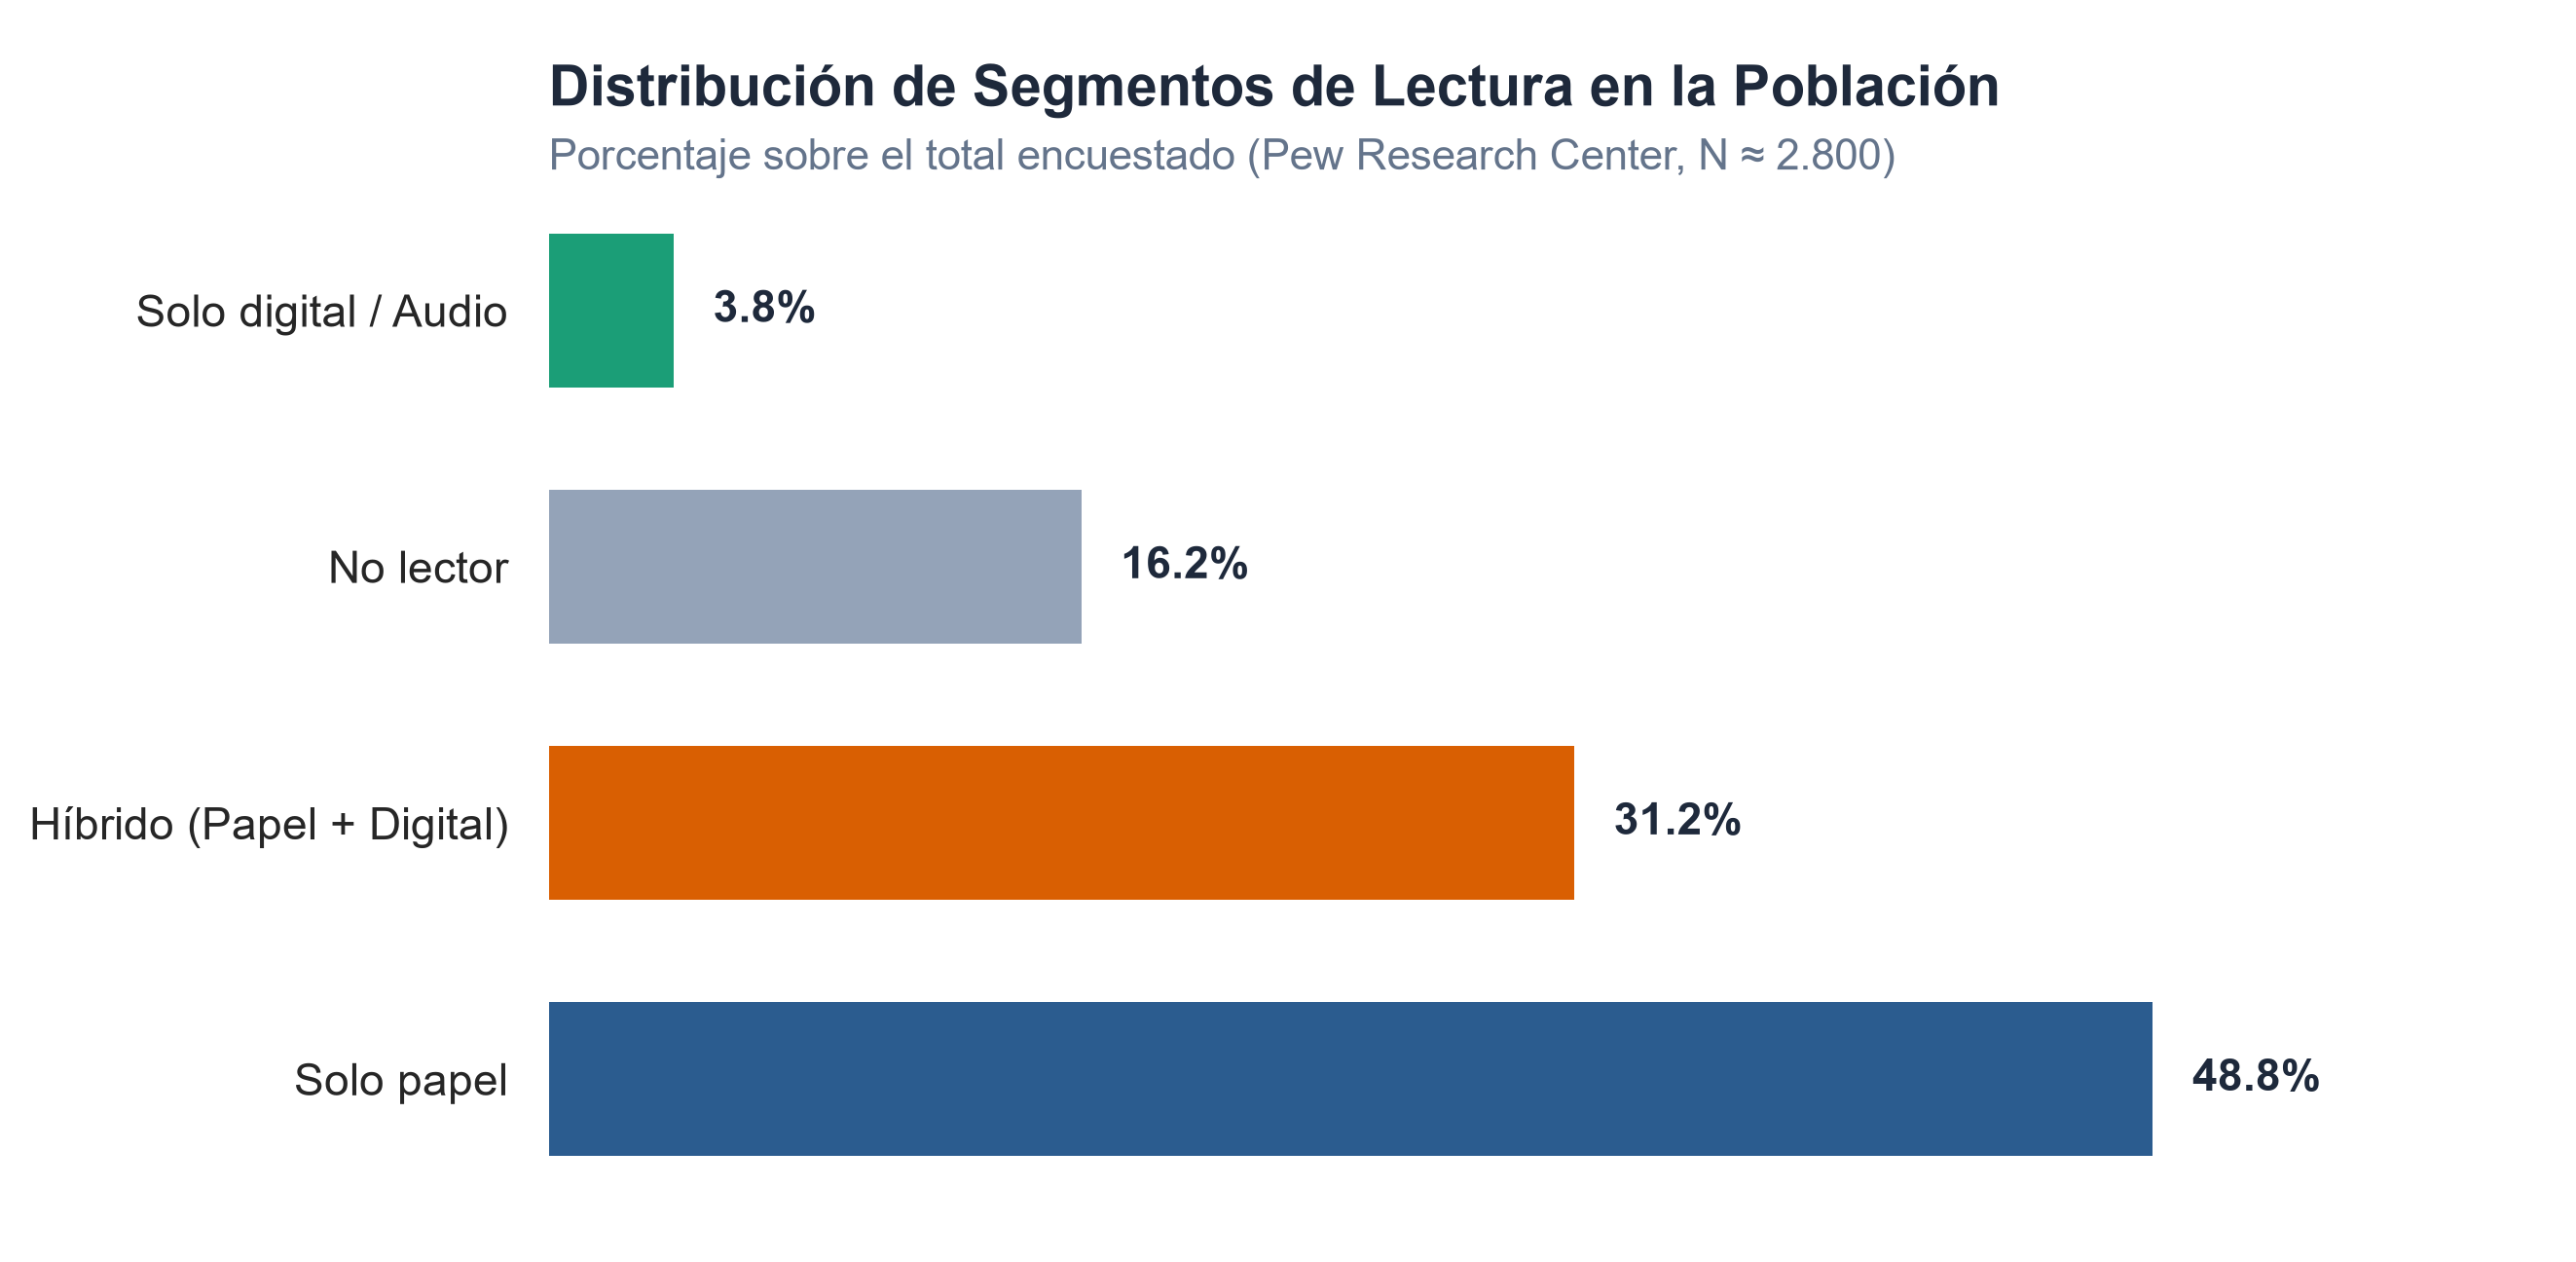

In [21]:
import importlib
import plotting as plot_utils

importlib.reload(plot_utils)
fig1 = plot_utils.plot_segments_distribution(df, figures_path)
plt.show()

Gráfico guardado en: c:\Users\micaa\book-consumption-analysis\figures\age_vs_digital_adoption.png


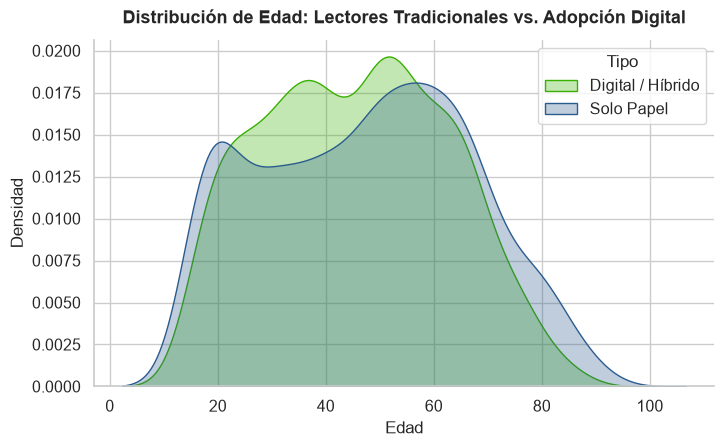

In [17]:
fig3 = plot_utils.plot_age_vs_adoption(df, figures_path)
plt.show()